In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification-v2' dataset.
Path to dataset files: /kaggle/input/garbage-classification-v2


In [ ]:
import os

dataset_path=path

print(os.listdir(dataset_path))

['standardized_384', 'original', 'standardized_256']


In [ ]:
import tensorflow as tf
import os

dataset_path = os.path.join(path, 'original')

dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(256, 256),
    batch_size=32,
    shuffle=True
)

print(dataset.class_names)

Found 12259 files belonging to 10 classes.
['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100
NUM_CLASSES = 10
SEED = 42

# Set random seeds for reproducibility
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
import tensorflow as tf
import os

data_dir = dataset_path
print("=" * 70)
print("TensorFlow-based validation (this will find the corrupted files)")
print("=" * 70)

def validate_with_tensorflow(directory):
    """
    Validate ALL images using TensorFlow's decoder.
    This catches files that PIL misses.
    """
    corrupted_files = []
    checked = 0

    for root, dirs, files in os.walk(directory):
        for file in files:
            if not file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
                continue

            file_path = os.path.join(root, file)
            checked += 1

            if checked % 1000 == 0:
                print(f"  Checked {checked} files...")

            try:
                # Read file
                img_raw = tf.io.read_file(file_path)

                # Try to decode with TensorFlow (this is what will fail during training)
                img = tf.image.decode_image(img_raw, channels=3, expand_animations=False)

                # Also try to resize (sometimes this fails too)
                img_resized = tf.image.resize(img, [224, 224])

            except Exception as e:
                print(f"\n❌ FOUND PROBLEMATIC FILE: {file_path}")
                print(f"   Error: {str(e)[:100]}")
                corrupted_files.append(file_path)

                # Remove the file
                try:
                    os.remove(file_path)
                    print(f"   ✓ Removed")
                except Exception as remove_err:
                    print(f"   ✗ Could not remove: {remove_err}")

    print(f"\n✅ Checked {checked} files")
    print(f"❌ Found and removed {len(corrupted_files)} corrupted files")

    return corrupted_files

# Run TensorFlow validation
corrupted = validate_with_tensorflow(data_dir)

if len(corrupted) > 0:
    print("\nCorrupted files removed:")
    for f in corrupted:
        print(f"  - {f}")

TensorFlow-based validation (this will find the corrupted files)
  Checked 1000 files...
  Checked 2000 files...
  Checked 3000 files...
  Checked 4000 files...
  Checked 5000 files...
  Checked 6000 files...
  Checked 7000 files...
  Checked 8000 files...
  Checked 9000 files...
  Checked 10000 files...
  Checked 11000 files...
  Checked 12000 files...

✅ Checked 12259 files
❌ Found and removed 0 corrupted files


In [ ]:
import tensorflow as tf
from tensorflow import keras
import gc

# Clear cache
gc.collect()

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
DATA_DIR = dataset_path
# 1. Create Training Dataset (70%)
train_dataset = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True
)
# 2. Create Validation+Test Dataset (30%)
val_test_dataset = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True
)


class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)

print(f"\nClasses: {class_names}")
print(f"Number of classes: {NUM_CLASSES}")

# 3. Split Validation into Val (15%) and Test (15%)

val_batches = tf.data.experimental.cardinality(val_test_dataset)
test_dataset = val_test_dataset.take(val_batches // 2)
val_dataset  = val_test_dataset.skip(val_batches // 2)

print(f"\nTraining batches: {tf.data.experimental.cardinality(train_dataset)}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_dataset)}")
print(f"Test batches: {tf.data.experimental.cardinality(test_dataset)}")

# 4. Performance Optimization
AUTOTUNE = tf.data.AUTOTUNE



train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("\n✅ Datasets ready and correctly split!")

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.

Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Number of classes: 10

Training batches: 269
Validation batches: 58
Test batches: 57

✅ Datasets ready and correctly split!


In [ ]:
def separable_conv_block(x, filters, kernel_size=3, strides=1, use_bias=False):
    x = layers.SeparableConv2D(
        filters,
        kernel_size,
        strides=strides,
        padding="same",
        use_bias=use_bias
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

In [ ]:
def residual_block(x, filters, use_pooling=False):

    residual = x

    x = separable_conv_block(x, filters, kernel_size=3)
    x = separable_conv_block(x, filters, kernel_size=3)

    if use_pooling:
        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
        residual = layers.Conv2D(filters, 1, strides=2, padding="same")(residual)
    elif filters != residual.shape[-1]:
        residual = layers.Conv2D(filters, 1, padding="same")(residual)

    x = layers.add([x, residual])
    return x

In [ ]:
def build_garbage_classifier():
    inputs = keras.Input(shape=(224, 224, 3))
    x = inputs

    # Data Augmentation
    x = layers.RandomFlip("horizontal_and_vertical")(x)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.RandomContrast(0.1)(x)
    x = layers.RandomBrightness(0.1)(x)
    x = layers.RandomTranslation(0.1, 0.1)(x)
    # Preprocessing
    x = layers.Rescaling(1.0 / 255)(x)

    # Initial Convolution Block
    x = layers.Conv2D(32, 5, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(64, 5, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # Residual Blocks
    # Block 1: 128 filters
    x = residual_block(x, filters=128, use_pooling=True)

    # Block 2: 256 filters
    x = residual_block(x, filters=256, use_pooling=False)

    # Block 3: 512 filters
    x = residual_block(x, filters=512, use_pooling=True)

    # High-Level Feature Extraction
    x = layers.SeparableConv2D(1024, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # Classification
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)


    model = keras.Model(inputs=inputs, outputs=outputs, name="garbage_classifier")
    return model

In [ ]:
# Build and display model summary
model = build_garbage_classifier()
model.summary()

Model: "garbage_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_1       │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_1   │ (None, 224, 224,  │          0 │ random_flip_1[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_1       │ (None, 224, 224,  │          0 │ random_rotation_… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast_1   │ (None, 224, 224,  │          0 │ random_zoom_1[0]… │
│ (RandomContrast)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_brightness_1 │ (None, 224, 224,  │          0 │ random_contrast_… │
│ (RandomBrightness)  │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 224, 224,  │          0 │ random_brightnes… │
│ (RandomTranslation) │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ random_translati… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 112, 112,  │      2,400 │ rescaling_1[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 56, 56,    │     51,200 │ activation_9[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_7  │ (None, 56, 56,    │      8,768 │ activation_10[0]… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 56, 56,    │          0 │ batch_normalizat

 Total params: 1,305,514 (4.98 MB)

 Trainable params: 1,299,690 (4.96 MB)

 Non-trainable params: 5,824 (22.75 KB)

## 4. Model Compilation And Model Training

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:

# model_save_path = "/content/garbage_classification_model.keras"

# # Define callbacks
# callbacks = [
#     keras.callbacks.ModelCheckpoint(
#         filepath=model_save_path,
#         save_best_only=True,
#         monitor="val_loss",
#         verbose=1
#     ),
#     keras.callbacks.ReduceLROnPlateau(
#         monitor="val_loss",
#         factor=0.2,
#         patience=3,
#         min_lr=1e-7,
#         verbose=1
#     ),
#     keras.callbacks.EarlyStopping(
#         monitor="val_loss",
#         patience=10,
#         restore_best_weights=True,
#         verbose=1
#     )
# ]

In [ ]:
# Train the model
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
268/269 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.2830 - loss: 2.1110
Epoch 1: val_loss did not improve from 0.93001
269/269 ━━━━━━━━━━━━━━━━━━━━ 59s 194ms/step - accuracy: 0.3213 - loss: 1.9951 - val_accuracy: 0.1819 - val_loss: 2.3778 - learning_rate: 0.0010
Epoch 2/50
268/269 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.3732 - loss: 1.8291
Epoch 2: val_loss did not improve from 0.93001
269/269 ━━━━━━━━━━━━━━━━━━━━ 49s 184ms/step - accuracy: 0.3873 - loss: 1.7892 - val_accuracy: 0.3022 - val_loss: 1.9423 - learning_rate: 0.0010
Epoch 3/50
268/269 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.4242 - loss: 1.6717
Epoch 3: val_loss did not improve from 0.93001

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
269/269 ━━━━━━━━━━━━━━━━━━━━ 53s 196ms/step - accuracy: 0.4314 - loss: 1.6543 - val_accuracy: 0.3896 - val_loss: 1.7521 - learning_rate: 0.0010
Epoch 4/50
268/269 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.4809 - loss: 1.50

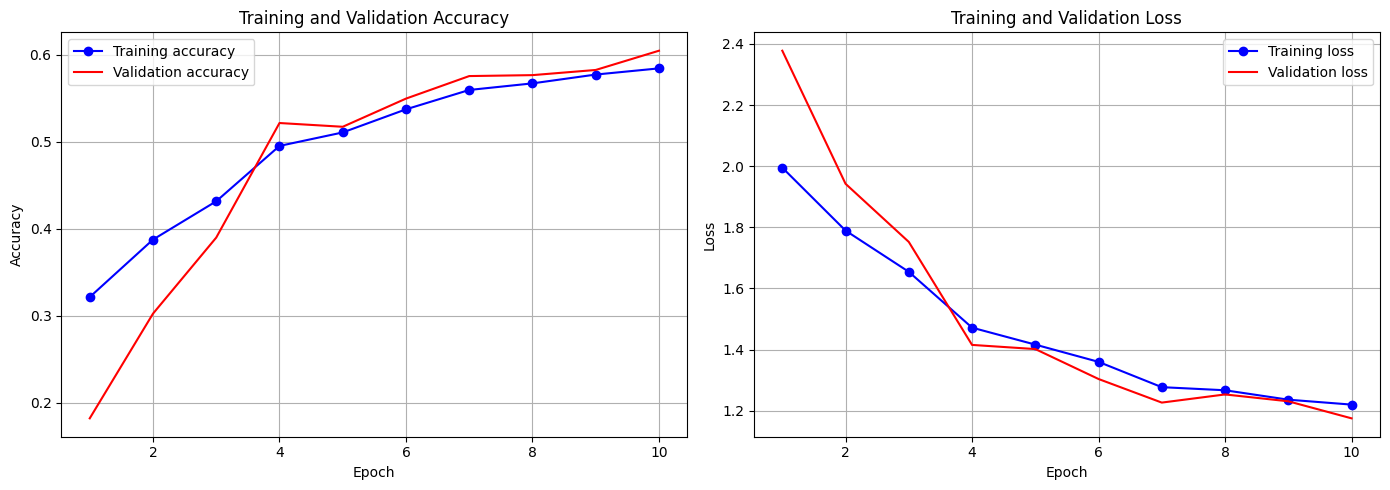

In [ ]:
def plot_training_history(history):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

## 6. Model Evaluation on Test Set and Confusion Matrix

In [ ]:
# Load best model
best_model = keras.models.load_model(model_save_path)

# Evaluate on test set
test_loss, test_acc = best_model.evaluate(test_dataset)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.6826 - loss: 0.9289

Test Accuracy: 0.6826
Test Loss: 0.9289


In [ ]:
# Generate predictions for confusion matrix
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

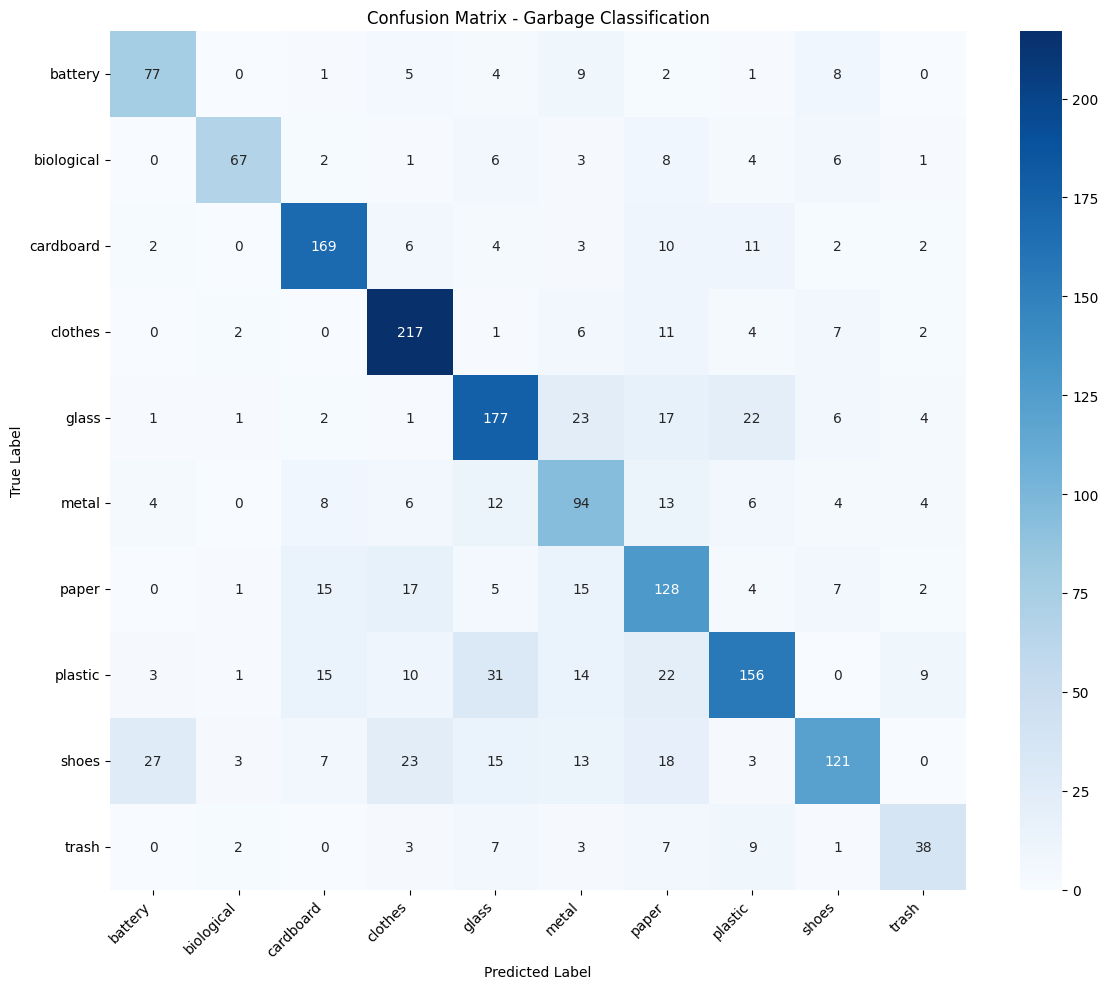

In [ ]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix - Garbage Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Print classification report
print("\nClassification Report:")
print("=" * 70)
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

     battery       0.68      0.72      0.70       107
  biological       0.87      0.68      0.77        98
   cardboard       0.77      0.81      0.79       209
     clothes       0.75      0.87      0.81       250
       glass       0.68      0.70      0.69       254
       metal       0.51      0.62      0.56       151
       paper       0.54      0.66      0.60       194
     plastic       0.71      0.60      0.65       261
       shoes       0.75      0.53      0.62       230
       trash       0.61      0.54      0.58        70

    accuracy                           0.68      1824
   macro avg       0.69      0.67      0.67      1824
weighted avg       0.69      0.68      0.68      1824



In [ ]:
# Find most common misclassifications
misclassification_pairs = []

for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            misclassification_pairs.append((
                class_names[i],
                class_names[j],
                cm[i, j]
            ))

# Sort by frequency
misclassification_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nTop 10 Misclassification Pairs:")
print("=" * 70)
for true_label, pred_label, count in misclassification_pairs[:10]:
    print(f"{true_label:15s} → {pred_label:15s}: {count:3d} times")


Top 10 Misclassification Pairs:
plastic         → glass          :  31 times
shoes           → battery        :  27 times
glass           → metal          :  23 times
shoes           → clothes        :  23 times
glass           → plastic        :  22 times
plastic         → paper          :  22 times
shoes           → paper          :  18 times
glass           → paper          :  17 times
paper           → clothes        :  17 times
paper           → cardboard      :  15 times
